# 📊 Green Bond Thesis — European Regression Pipeline
**Title:** Do Politicians' Words Have a Dollar Value? — European Robustness Extension  
**Author:** Nahian Ibnat  
**Supervisor:** Zoltán Csaba Tóth  
**Institution:** Central European University — MA in Economics, Data & Policy  
**Date:** May 2026

---

## What This Notebook Does

This notebook replicates the full empirical strategy of the Asia chapter (India & Indonesia) on European sovereign green bond markets (Germany & Denmark). The purpose is to provide a **methodological validation**: if the pipeline detects effects in liquid, mature European markets, null results in Asia can be attributed to market immaturity rather than methodological failure.

| Part | Content |
|------|---------|
| **Part 1** | Setup — packages, file paths, helper functions |
| **Part 2** | Data loading — bond yields, sentiment, controls |
| **Part 3** | Panel construction — Greenium, merging, first-differencing |
| **Part 4** | Main regression — pooled M1–M5 + country-specific DiD |
| **Part 4b** | Stacked DiD robustness check |
| **Part 5** | ClimateBERT robustness (skipped — see note) |
| **Part 6** | Visualisation — four publication-quality charts |
| **Part 7** | Save outputs |

### Folder Structure
```
Thesis/
├── notebooks/
│   └── GreenBond_Regression_Europe.ipynb   ← this file
├── data/
│   ├── raw/
│   │   ├── bond_yield_data/
│   │   │   ├── germany_bond/
│   │   │   └── denmark_bond/
│   │   └── control_variables/
│   │       ├── vix/
│   │       ├── exchange_rate/
│   │       └── cds/
│   └── processed/
│       └── gdelt/
│           └── daily_sentiment_gdelt_europe.csv   ← V2Tone for Germany & Denmark
└── output/
    └── regression_europe/
```

### Twin-Bond Design (Zerbib 2019)
Both European pairs use a **strict twin-bond design**: identical coupon and maturity date, issued by the same sovereign. This eliminates duration mismatch and issuer risk as confounders — a cleaner identification than the Asia chapter's maturity-matched pairs.

| Pair | Green Bond | Conventional Twin | Green issued | Pre-treatment data |
|------|-----------|------------------|-------------|-------------------|
| Germany 10Y | DE0001030708 (0% Aug 2030) | DE0001102507 (0% Aug 2030) | 2 Sep 2020 | ✅ None (inaugural) |
| Denmark 10Y | DK0009924375 (0% Nov 2031) | DK0009924102 (0% Nov 2031) | 21 Jan 2022 | ✅ Germany as control |

> **Run all cells sequentially top to bottom.**


---
# Part 1 — Setup


## 1.1 — Install Dependencies


In [1]:
!pip install -q openpyxl pandas numpy statsmodels matplotlib scipy

## 1.2 — Imports


In [2]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported.")


✓ All libraries imported.


## 1.3 — File Paths

All paths are relative to the `Thesis/` root via `ROOT = os.path.abspath("..")`.  
The notebook auto-detects ROOT — no manual path changes needed as long as the notebook lives in `Thesis/notebooks/`.


In [3]:
ROOT = '..'  # Notebook lives in Thesis/notebooks/

BOND_FILES = {
    'DEU_GREEN_10Y': os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'germany_bond', 'DEU_GREEN_10Y_DE0001030708.xlsx'),
    'DEU_CONV_10Y':  os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'germany_bond', 'DEU_CONV_10Y_DE0001102507.xlsx'),
    'DNK_GREEN_10Y': os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'denmark_bond', 'DNK_GREEN_10Y_DK0009924375.xlsx'),
    'DNK_CONV_10Y':  os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'denmark_bond', 'DNK_CONV_10Y_DK0009924102.xlsx'),
}

VIX_FILE      = os.path.join(ROOT, 'data', 'raw', 'control_variables', 'vix',           'VIXCLS.csv')
EURUSD_FILE   = os.path.join(ROOT, 'data', 'raw', 'control_variables', 'exchange_rate', 'CTRL_EURUSD_01Jan2019_18May2026.csv')
USDDKK_FILE   = os.path.join(ROOT, 'data', 'raw', 'control_variables', 'exchange_rate', 'CTRL_USDDKK_01Jan2019_18May2026.csv')
CDS_DEU_FILE  = os.path.join(ROOT, 'data', 'raw', 'control_variables', 'cds',           'CTRL_CDS5Y_Germany_DEGV5YUSAC.csv')
SENTIMENT_FILE = os.path.join(ROOT, 'data', 'processed', 'gdelt', 'daily_sentiment_gdelt_europe.csv')

# ── Treatment dates ───────────────────────────────────────────────────────
TREATMENT_DEU = pd.Timestamp("2020-09-02")  # Germany inaugural green Bund
TREATMENT_DNK = pd.Timestamp("2022-01-21")  # Denmark inaugural green bond
TREATMENT_EUGB = pd.Timestamp("2023-02-28") # EuGB provisional agreement

EVENTS = {
    "2020-09-02": "Germany\nGreen Bund",
    "2022-01-21": "Denmark\nGreen Bond",
    "2023-02-28": "EuGB\nAgreement",
}

OUTPUT_FOLDER = os.path.join(ROOT, 'output', 'regression')
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
print("✓ File paths configured.")
print(f"Output folder: {OUTPUT_FOLDER}")


✓ File paths configured.
Output folder: ..\output\regression


## 1.4 — Helper Functions & Chart Styling


In [4]:
import openpyxl

def load_bond_ytm(filepath):
    """Load Refinitiv bond file → daily mid-YTM series."""
    wb = openpyxl.load_workbook(filepath)
    ws = wb.active
    rows = list(ws.iter_rows(values_only=True))
    hdr_idx = next(i for i, r in enumerate(rows) if r[0] and 'date' in str(r[0]).lower())
    df = pd.DataFrame([r for r in rows[hdr_idx+1:] if r[0] is not None], columns=rows[hdr_idx])
    df['date'] = pd.to_datetime(df['Date'])
    df['ytm']  = (df['BidYld'] + df['AskYld']) / 2
    return df[['date','ytm']].dropna().sort_values('date').reset_index(drop=True)

def load_fx(filepath, col_name):
    """Load Refinitiv FX Price History → daily mid-rate series."""
    wb = openpyxl.load_workbook(filepath)
    ws = wb.active
    rows = list(ws.iter_rows(values_only=True))
    hdr_idx = next(i for i, r in enumerate(rows)
                   if r[0] and 'exchange date' in str(r[0]).lower())
    df = pd.DataFrame([r for r in rows[hdr_idx+1:] if r[0] is not None], columns=rows[hdr_idx])
    df['date']   = pd.to_datetime(df['Exchange Date'])
    df[col_name] = (df['Bid'] + df['Ask']) / 2
    return df[['date',col_name]].dropna().sort_values('date')

def load_cds(filepath, col_name):
    """Load Investing.com CDS CSV."""
    df = pd.read_csv(filepath)
    df.columns = ['date',col_name,'open','high','low','chg']
    df['date'] = pd.to_datetime(df['date'])
    return df[['date',col_name]].dropna()

def run_ols(x_cols, data, y='greenium_fd'):
    """OLS with HC3 heteroskedasticity-robust standard errors."""
    X = sm.add_constant(data[x_cols])
    return OLS(data[y], X).fit(cov_type='HC3')

def print_regression_table(results_dict, model_keys, key_vars, var_labels, title):
    """Print formatted regression results table."""
    print(f'\n{title}')
    print('=' * 85)
    print(f"{'Variable':<28}" + "".join(f"{m:<17}" for m in model_keys))
    print('-' * 85)
    for v in key_vars:
        row = f"{var_labels.get(v,v):<28}"
        for m in model_keys:
            res = results_dict[m]
            if v in res.params.index:
                c=res.params[v]; p=res.pvalues[v]
                stars='***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
                row += f"{c:+.4f}{stars:<3}{'':>8}"
            else:
                row += f"{'—':<17}"
        print(row)
    print('-' * 85)
    for stat, fn in [('N', lambda r: str(int(r.nobs))),
                     ('R²', lambda r: f'{r.rsquared:.4f}'),
                     ('Adj R²', lambda r: f'{r.rsquared_adj:.4f}')]:
        print(f"{stat:<28}" + "".join(f"{fn(results_dict[m]):<17}" for m in model_keys))
    print('\n* p<0.1  ** p<0.05  *** p<0.01  |  HC3 robust SE  |  Standardised regressors')

# Chart styling
TEAL='#1D9E75'; ORANGE='#E85D24'; BLUE='#4C9BE8'; PURPLE='#c084fc'
GRAY='#8892a4'; WHITE='#e8eaf0'; BG='#0f1117'; PANEL_BG='#1a1d27'

def style_ax(ax):
    ax.set_facecolor(PANEL_BG)
    ax.tick_params(colors=GRAY, labelsize=8)
    ax.xaxis.label.set_color(GRAY); ax.yaxis.label.set_color(GRAY)
    ax.title.set_color(WHITE)
    for s in ax.spines.values(): s.set_edgecolor('#2a2d3a')

print("✓ Helper functions and chart styling defined.")


✓ Helper functions and chart styling defined.


---
# Part 2 — Data Loading


## 2.1 — Bond Yield Data (Refinitiv Eikon)

Daily Bid/Ask yields for 4 sovereign bonds — 2 German, 2 Danish. Mid-YTM = (BidYld + AskYld) / 2.

**Germany:** The green Bund (DE0001030708) and its conventional twin (DE0001102507) share identical coupon (0%) and maturity (15 Aug 2030), issued under the Deutsche Finanzagentur's twin-bond programme. The conventional bond was issued first (Aug 2019); the green bond followed on 2 Sep 2020. Data begins on the green bond's first trading day.  

**Denmark:** The green bond (DK0009924375) and its conventional twin (DK0009924102) share identical coupon (0%) and maturity (15 Nov 2031). Denmark's first sovereign green bond was issued on 21 Jan 2022 under Danmarks Nationalbank's twin-bond programme.


In [5]:
bond_dfs = {}
print(f"{'Bond':<22} {'Obs':>5}  {'Start':<12} {'End':<12}  {'YTM Range'}")
print("-" * 65)
for key, fpath in BOND_FILES.items():
    bond_dfs[key] = load_bond_ytm(fpath)
    df = bond_dfs[key]
    print(f"{key:<22} {len(df):>5}  {str(df.date.min().date()):<12} "
          f"{str(df.date.max().date()):<12}  {df.ytm.min():.3f}–{df.ytm.max():.3f}")
print(f"\n✓ {len(bond_dfs)} bond files loaded.")


Bond                     Obs  Start        End           YTM Range
-----------------------------------------------------------------
DEU_GREEN_10Y           1488  2020-09-03   2026-05-18    -0.679–2.842
DEU_CONV_10Y            1543  2020-06-18   2026-05-18    -0.643–2.858


DNK_GREEN_10Y           1132  2022-01-14   2026-05-18    0.002–3.137
DNK_CONV_10Y            1389  2021-01-20   2026-05-18    -0.381–3.159

✓ 4 bond files loaded.


## 2.2 — Control Variables

| Variable | Source | Role |
|----------|--------|------|
| VIX | FRED | Global risk appetite — forward-filled over weekends |
| EUR/USD | Investing.com | Currency risk — Germany |
| DKK/USD | Investing.com (inverted from USD/DKK) | Currency risk — Denmark |
| Germany CDS 5Y | Investing.com | Sovereign credit risk proxy for both countries |

**Note on Denmark CDS:** Denmark 5Y CDS data is unavailable on Investing.com. Germany CDS is used as a shared proxy — both are AAA-rated sovereigns with near-identical credit profiles and highly correlated CDS dynamics within the eurozone.


In [6]:
# VIX — same FRED file as Asia chapter
vix = pd.read_csv(VIX_FILE)
vix.columns = ['date','vix']
vix['date'] = pd.to_datetime(vix['date'])
vix = vix[vix['vix'] != '.'].copy()
vix['vix'] = pd.to_numeric(vix['vix'])

# FX — Investing.com format: Date, Price, Open, High, Low, Vol, Change%
def load_investing_fx(filepath, col_name):
    df = pd.read_csv(filepath)
    df['date'] = pd.to_datetime(df['Date'])
    df[col_name] = pd.to_numeric(df['Price'], errors='coerce')
    return df[['date', col_name]].dropna().sort_values('date')

eurusd = load_investing_fx(EURUSD_FILE, 'eurusd')
usddkk = load_investing_fx(USDDKK_FILE, 'usddkk')
# DKK/USD = 1 / USD/DKK
usddkk['dkkusd'] = 1 / usddkk['usddkk']
usddkk = usddkk[['date','dkkusd']]

# CDS — Investing.com format
cds_deu = pd.read_csv(CDS_DEU_FILE)
cds_deu.columns = ['date','cds_germany','open','high','low','chg']
cds_deu['date'] = pd.to_datetime(cds_deu['date'])
cds_deu = cds_deu[['date','cds_germany']].dropna()

print(f"{'Variable':<20} {'Obs':>5}  {'Start':<12} {'End':<12}")
print("-" * 52)
for name, df in [('VIX',vix),('EUR/USD',eurusd),('DKK/USD',usddkk),('CDS Germany',cds_deu)]:
    print(f"{name:<20} {len(df):>5}  {str(df['date'].min().date()):<12} {str(df['date'].max().date()):<12}")
print("\n✓ Control variables loaded.")


Variable               Obs  Start        End         
----------------------------------------------------
VIX                   1641  2020-01-02   2026-04-16  
EUR/USD               1927  2019-01-01   2026-05-18  
DKK/USD               1927  2019-01-01   2026-05-18  
CDS Germany           1877  2019-01-01   2026-05-14  

✓ Control variables loaded.


## 2.3 — Sentiment Data (GDELT V2Tone)

The sentiment file `daily_sentiment_gdelt_europe.csv` contains:

| Column | Description | Use in thesis |
|--------|-------------|---------------|
| `sentiment_gdelt` | GDELT V2Tone daily mean score | **Primary variable** — H1, H2 |
| `sentiment_std` | Std of article-level V2Tone | **Signaling Noise** — H2 |
| `sentiment_climatebert` | ClimateBERT score (placeholder 0.0) | Not used — robustness skipped |

**Coverage:** Germany ~89,000 articles | Denmark ~88,000 articles | Jan 2019 – May 2026, zero missing days.  

**ClimateBERT note:** Unlike the Asia chapter, ClimateBERT robustness is not run for the European extension. The Asia analysis established that ClimateBERT on GDELT theme codes returns predominantly neutral scores (coverage 1.4%), making it an unreliable robustness instrument. V2Tone is the sole sentiment variable here.


In [7]:
sent = pd.read_csv(SENTIMENT_FILE, parse_dates=['date'])

print(f"Sentiment file coverage: {sent.date.min().date()} → {sent.date.max().date()}")
print(f"Total country-days: {len(sent):,}")
print(f"Columns: {sent.columns.tolist()}")
print()
print(sent.groupby('country').agg(
    days       = ('date',           'nunique'),
    mean_sent  = ('sentiment_gdelt', 'mean'),
    mean_noise = ('sentiment_std',   'mean'),
).round(4).to_string())
print("\n✓ Sentiment data loaded.")


Sentiment file coverage: 2019-01-01 → 2026-05-01
Total country-days: 5,322
Columns: ['country', 'date', 'sentiment_gdelt', 'sentiment_climatebert', 'sentiment_std', 'article_count', 'pct_positive', 'pct_negative']

         days  mean_sent  mean_noise
country                             
Denmark  2661    -0.0439      0.2940
Germany  2661    -0.0940      0.2974

✓ Sentiment data loaded.


---
# Part 3 — Panel Construction


## 3.1 — Compute Greenium

$$\Delta y_{i,t} = \text{YTM}^{\text{green}}_{i,t} - \text{YTM}^{\text{conv}}_{i,t}$$

Negative Greenium = green bond trades at **lower yield** than its conventional twin = investors accept a lower return to hold the green label.

Both pairs use exact twin-bonds (identical coupon + maturity), so the spread is a model-free measure of the greenium — no interpolation or duration adjustment required.

**Expected values (from literature):** Germany ~−2 to −5bp | Denmark ~−2 to −4bp (Ando et al. 2023).


In [8]:
PAIRS = [
    # (green_key, conv_key, country, tenor)
    ('DEU_GREEN_10Y', 'DEU_CONV_10Y', 'Germany', '10Y'),
    ('DNK_GREEN_10Y', 'DNK_CONV_10Y', 'Denmark', '10Y'),
]

panels = []
print(f"{'Pair':<22} {'Obs':>5}  {'Start':<12} {'End':<12}  {'Mean Greenium':>14}")
print("-" * 70)
for gkey, ckey, country, tenor in PAIRS:
    g = bond_dfs[gkey].rename(columns={'ytm':'ytm_green'})
    c = bond_dfs[ckey].rename(columns={'ytm':'ytm_conv'})
    m = pd.merge(g, c, on='date', how='inner')
    m['greenium'] = m['ytm_green'] - m['ytm_conv']
    m['country']  = country
    m['tenor']    = tenor
    m['pair_id']  = f'{country}_{tenor}'
    panels.append(m)
    print(f"{country+' '+tenor:<22} {len(m):>5}  "
          f"{str(m.date.min().date()):<12} {str(m.date.max().date()):<12}  "
          f"{m.greenium.mean():>+14.4f} pp")

panel = pd.concat(panels, ignore_index=True)
print(f"\nTotal panel rows: {len(panel):,}")
print("✓ Greenium panel constructed.")


Pair                     Obs  Start        End            Mean Greenium
----------------------------------------------------------------------
Germany 10Y             1488  2020-09-03   2026-05-18           -0.0182 pp
Denmark 10Y             1132  2022-01-14   2026-05-18           -0.0278 pp

Total panel rows: 2,620
✓ Greenium panel constructed.


## 3.2 — Merge All Variables

Merges sentiment, VIX, FX, and CDS into the greenium panel.

**Key decisions:**
- VIX forward-filled over non-trading days (FRED publishes US trading days only)
- FX matched by country: EUR/USD for Germany, DKK/USD for Denmark
- CDS shared: Germany 5Y used for both countries (Denmark CDS unavailable)
- No date restriction applied — full twin-bond history used (Germany from Sep 2020, Denmark from Jan 2022)
- Treatment dummies: Germany post = 1 from 2-Sep-2020 | Denmark post = 1 from 21-Jan-2022


In [9]:
# Merge sentiment by country
sent_deu = sent[sent['country']=='Germany'][['date','sentiment_gdelt','sentiment_std']].copy()
sent_deu = sent_deu.rename(columns={'sentiment_gdelt':'sentiment','sentiment_std':'signaling_noise'})
sent_dnk = sent[sent['country']=='Denmark'][['date','sentiment_gdelt','sentiment_std']].copy()
sent_dnk = sent_dnk.rename(columns={'sentiment_gdelt':'sentiment','sentiment_std':'signaling_noise'})

deu_p = panel[panel['country']=='Germany'].merge(sent_deu, on='date', how='left')
dnk_p = panel[panel['country']=='Denmark'].merge(sent_dnk, on='date', how='left')
panel = pd.concat([deu_p, dnk_p], ignore_index=True)

# VIX — forward-fill
vix_ff = (vix.set_index('date')
             .reindex(pd.date_range(panel.date.min(), panel.date.max()))
             .ffill().reset_index())
vix_ff.columns = ['date','vix']
panel = panel.merge(vix_ff, on='date', how='left')

# FX — Germany uses EUR/USD, Denmark uses DKK/USD
panel = panel.merge(eurusd, on='date', how='left')
panel = panel.merge(usddkk, on='date', how='left')
panel['fx'] = np.where(panel['country']=='Germany', panel['eurusd'], panel['dkkusd'])
panel = panel.drop(columns=['eurusd','dkkusd'])

# CDS — Germany CDS for both (Denmark CDS unavailable; both AAA, highly correlated)
panel = panel.merge(cds_deu, on='date', how='left')
panel['cds'] = panel['cds_germany']
panel = panel.drop(columns=['cds_germany'])

# Log transforms
panel['log_fx']  = np.log(panel['fx'])
panel['log_vix'] = np.log(panel['vix'])

# Post treatment dummy — country-specific treatment dates
panel['post'] = np.where(
    panel['country']=='Germany',
    (panel['date'] >= TREATMENT_DEU).astype(int),
    (panel['date'] >= TREATMENT_DNK).astype(int)
)

# Restrict to complete cases
panel = panel.dropna(subset=['sentiment','signaling_noise','vix','cds','fx']).reset_index(drop=True)

print("Final panel summary:")
print(panel.groupby(['country','tenor']).agg(
    obs=('date','count'), start=('date','min'), end=('date','max'),
    greenium_mean=('greenium','mean'), greenium_std=('greenium','std'),
).round(4).to_string())
print(f"\nTotal: {len(panel):,} obs")
print("✓ Panel merged.")


Final panel summary:
                obs      start        end  greenium_mean  greenium_std
country tenor                                                         
Denmark 10Y    1064 2022-01-14 2026-05-01        -0.0272        0.0191
Germany 10Y    1420 2020-09-03 2026-05-01        -0.0178        0.0197

Total: 2,484 obs
✓ Panel merged.


## 3.3 — Descriptive Statistics


In [10]:
desc = panel[['greenium','sentiment','signaling_noise','vix','cds','fx']].describe().T
desc = desc[['mean','std','min','25%','50%','75%','max']]
desc.columns = ['Mean','Std','Min','P25','Median','P75','Max']
print("Descriptive Statistics — Full Panel")
print("=" * 75)
print(desc.round(4).to_string())
print("\nGreenium by country:")
print(panel.groupby('country')['greenium'].describe().round(4).to_string())
print("\nCorrelation matrix:")
print(panel[['greenium','sentiment','signaling_noise','log_vix','cds','log_fx']].corr().round(3).to_string())


Descriptive Statistics — Full Panel
                    Mean     Std      Min      P25   Median      P75      Max
greenium         -0.0218  0.0200  -0.1875  -0.0313  -0.0178  -0.0090   0.0481
sentiment        -0.0671  0.0736  -0.3677  -0.1159  -0.0658  -0.0204   0.2288
signaling_noise   0.3023  0.0489   0.1085   0.2692   0.3004   0.3318   0.5817
vix              19.3767  5.4450  11.8600  15.3700  17.9900  22.2900  52.3300
cds              12.7145  4.1305   6.2600   9.5200  11.8350  15.0100  27.5000
fx                0.6995  0.4811   0.1290   0.1465   1.0492   1.1192   1.2325

Greenium by country:
          count    mean     std     min     25%     50%     75%     max
country                                                                
Denmark  1064.0 -0.0272  0.0191 -0.1875 -0.0336 -0.0255 -0.0167  0.0481
Germany  1420.0 -0.0178  0.0197 -0.0680 -0.0242 -0.0135 -0.0050  0.0460

Correlation matrix:
                 greenium  sentiment  signaling_noise  log_vix    cds  log_fx
greenium 

## 3.4 — First-Differencing

Removes pair-level fixed effects and serial correlation within bond pairs.

$$\Delta x_{i,t} = x_{i,t} - x_{i,t-1} \quad \text{within each bond pair}$$

All continuous regressors are standardised after differencing (mean=0, SD=1) to make coefficients directly comparable across models and across the Asia/Europe chapters.

**Expected improvement in serial correlation:** Durbin-Watson in levels ≈ 0.4 → after differencing ≈ 2.0 (consistent with Asia chapter results).


In [11]:
panel = panel.sort_values(['pair_id','date']).reset_index(drop=True)

fd_cols = ['greenium','sentiment','signaling_noise','log_vix','log_fx','cds']
# Include ClimateBERT if available
if 'sentiment_climatebert' in panel.columns:
    fd_cols.append('sentiment_climatebert')

for col in fd_cols:
    panel[f'{col}_fd'] = panel.groupby('pair_id')[col].diff()

panel_fd = panel.dropna(subset=['greenium_fd']).reset_index(drop=True)

print(f"Before first-differencing: {len(panel):,}")
print(f"After first-differencing:  {len(panel_fd):,}")
print(f"Lost (first obs per pair): {len(panel) - len(panel_fd)}")

# Standardise
std_cols = ['sentiment_fd','signaling_noise_fd','log_vix_fd','log_fx_fd','cds_fd']
if 'sentiment_climatebert_fd' in panel_fd.columns:
    std_cols.append('sentiment_climatebert_fd')

for col in std_cols:
    panel_fd[f'{col}_z'] = (panel_fd[col] - panel_fd[col].mean()) / panel_fd[col].std()

panel_fd['sent_x_noise'] = panel_fd['sentiment_fd_z'] * panel_fd['signaling_noise_fd_z']

print("\n✓ First-differencing complete. All _fd_z variables: mean=0, SD=1.")


Before first-differencing: 2,484
After first-differencing:  2,482
Lost (first obs per pair): 2

✓ First-differencing complete. All _fd_z variables: mean=0, SD=1.


## 3.5 — Country Subsets


In [12]:
panel_deu = panel_fd[panel_fd['country']=='Germany'].copy().reset_index(drop=True)
panel_dnk = panel_fd[panel_fd['country']=='Denmark'].copy().reset_index(drop=True)

for name, df in [('Germany', panel_deu), ('Denmark', panel_dnk)]:
    print(f"{name}: {len(df):,} obs | {df.date.min().date()} → {df.date.max().date()}")
    print(f"  Pairs: {df['pair_id'].unique().tolist()}")
    print(f"  Mean ΔGreenium: {df['greenium_fd'].mean():+.5f} pp")
    print()
print("✓ Country subsets ready.")


Germany: 1,419 obs | 2020-09-04 → 2026-05-01
  Pairs: ['Germany_10Y']
  Mean ΔGreenium: -0.00000 pp

Denmark: 1,063 obs | 2022-01-17 → 2026-05-01
  Pairs: ['Denmark_10Y']
  Mean ΔGreenium: +0.00012 pp

✓ Country subsets ready.


---
# Part 4 — Regression Models

## Model Specifications

| Model | Specification | Hypothesis |
|-------|--------------|------------|
| M1 | ΔSentiment + pair FE | H1 baseline |
| M2 | + Δlog(VIX), ΔCDS, Δlog(FX) | H1 controlled |
| M3 | + ΔSignaling Noise | H2 |
| M4 | + ΔSentiment × ΔNoise | H2 mechanism |
| M5 | + Post treatment + monthly time FE | H3 pooled DiD |
| M5-Germany | M5 on Germany only | H3 Germany |
| M5-Denmark | M5 on Denmark only | H3 Denmark |

All models: first-differenced variables, HC3 robust SE, standardised regressors.

**Identification strategy:** identical to Asia chapter — within-pair first-differencing eliminates pair-level fixed effects; monthly time dummies absorb common macro shocks in M5.


## 4.1 — Pooled Fixed Effects


In [13]:
pair_dummies = pd.get_dummies(panel_fd['pair_id'], drop_first=True, dtype=float)
time_dummies = pd.get_dummies(panel_fd['date'].dt.to_period('M').astype(str),
                              drop_first=True, dtype=float)
panel_fd = pd.concat([panel_fd, pair_dummies, time_dummies], axis=1)
fe_cols   = list(pair_dummies.columns)
time_cols = list(time_dummies.columns)

print(f"Pair FE: {fe_cols}")
print(f"Time FE: {len(time_cols)} monthly dummies")
print("✓ Fixed effects constructed.")


Pair FE: ['Germany_10Y']
Time FE: 67 monthly dummies
✓ Fixed effects constructed.


## 4.2 — Pooled Models M1–M5


In [14]:
results = {}

results['M1'] = run_ols(['sentiment_fd_z'] + fe_cols, panel_fd)
results['M2'] = run_ols(['sentiment_fd_z','log_vix_fd_z','cds_fd_z','log_fx_fd_z'] + fe_cols, panel_fd)
results['M3'] = run_ols(['sentiment_fd_z','signaling_noise_fd_z','log_vix_fd_z','cds_fd_z','log_fx_fd_z'] + fe_cols, panel_fd)
results['M4'] = run_ols(['sentiment_fd_z','signaling_noise_fd_z','sent_x_noise',
                          'log_vix_fd_z','cds_fd_z','log_fx_fd_z'] + fe_cols, panel_fd)
results['M5'] = run_ols(['post','sentiment_fd_z','log_vix_fd_z','cds_fd_z','log_fx_fd_z']
                         + fe_cols + time_cols, panel_fd)

KEY_VARS = ['sentiment_fd_z','signaling_noise_fd_z','sent_x_noise',
            'log_vix_fd_z','cds_fd_z','log_fx_fd_z','post']
VAR_LABELS = {
    'sentiment_fd_z':       'ΔSentiment (H1)',
    'signaling_noise_fd_z': 'ΔSignaling Noise (H2)',
    'sent_x_noise':         'ΔSentiment × ΔNoise',
    'log_vix_fd_z':         'Δlog(VIX)',
    'cds_fd_z':             'ΔCDS Spread',
    'log_fx_fd_z':          'Δlog(FX Rate)',
    'post':                 'Post Treatment (H3)',
}

print_regression_table(results, ['M1','M2','M3','M4','M5'], KEY_VARS, VAR_LABELS,
                        "POOLED REGRESSION RESULTS — FIRST-DIFFERENCED")
print("Pair FE: M1–M5  |  Time FE: M5 only")



POOLED REGRESSION RESULTS — FIRST-DIFFERENCED
Variable                    M1               M2               M3               M4               M5               
-------------------------------------------------------------------------------------
ΔSentiment (H1)             +0.0002           +0.0002           +0.0002           +0.0002           +0.0002           
ΔSignaling Noise (H2)       —                —                +0.0002           +0.0002           —                
ΔSentiment × ΔNoise         —                —                —                -0.0001           —                
Δlog(VIX)                   —                +0.0000           +0.0000           +0.0000           +0.0000           
ΔCDS Spread                 —                -0.0001           -0.0001           -0.0001           -0.0001           
Δlog(FX Rate)               —                -0.0002           -0.0002           -0.0002           -0.0002           
Post Treatment (H3)         —                —   

## 4.3 — Diagnostic Tests


In [15]:
print("DIAGNOSTIC TESTS")
print("=" * 55)
for mname in ['M3','M5']:
    res  = results[mname]
    dw   = sm.stats.stattools.durbin_watson(res.resid)
    jb_p = sm.stats.stattools.jarque_bera(res.resid)[1]
    print(f"\n[{mname}]")
    print(f"  Durbin-Watson : {dw:.4f}  (target ~2.0)")
    print(f"  Jarque-Bera p : {jb_p:.4f}  (>0.05 = normal)")

print("\nVIF — M3 key regressors:")
X_vif = sm.add_constant(panel_fd[['sentiment_fd_z','signaling_noise_fd_z',
                                    'log_vix_fd_z','cds_fd_z','log_fx_fd_z']])
for i, col in enumerate(X_vif.columns):
    if col != 'const':
        vif = variance_inflation_factor(X_vif.values, i)
        print(f"  {col:<28} VIF = {vif:.3f}{'  ← HIGH' if vif>10 else ''}")
print("  VIF < 2: excellent  |  VIF < 5: good  |  VIF < 10: acceptable")


DIAGNOSTIC TESTS

[M3]
  Durbin-Watson : 2.8603  (target ~2.0)
  Jarque-Bera p : 0.0000  (>0.05 = normal)

[M5]
  Durbin-Watson : 2.8791  (target ~2.0)
  Jarque-Bera p : 0.0000  (>0.05 = normal)

VIF — M3 key regressors:
  sentiment_fd_z               VIF = 1.000
  signaling_noise_fd_z         VIF = 1.001
  log_vix_fd_z                 VIF = 1.032
  cds_fd_z                     VIF = 1.011
  log_fx_fd_z                  VIF = 1.035
  VIF < 2: excellent  |  VIF < 5: good  |  VIF < 10: acceptable


## 4.4 — Germany: Country-Specific DiD

**Treatment:** 2-Sep-2020 — Germany's inaugural sovereign green bond (10Y green Bund, €6.5bn, twin-bond design)  
**Parallel trends:** Cannot be formally tested for Germany because the green bond data begins on the treatment date by construction (the green bond did not exist before issuance). The twin-bond matching design satisfies parallel trends by construction — identical coupon, maturity, and issuer as the conventional twin.


In [16]:
pair_dummies_deu = pd.get_dummies(panel_deu['pair_id'], drop_first=True, dtype=float)
time_dummies_deu = pd.get_dummies(panel_deu['date'].dt.to_period('M').astype(str),
                                   drop_first=True, dtype=float)
panel_deu = pd.concat([panel_deu, pair_dummies_deu, time_dummies_deu], axis=1)
fe_cols_deu   = list(pair_dummies_deu.columns)
time_cols_deu = list(time_dummies_deu.columns)

results['M5_Germany'] = run_ols(
    ['post','sentiment_fd_z','log_vix_fd_z','cds_fd_z','log_fx_fd_z']
    + fe_cols_deu + time_cols_deu, panel_deu)

DID_VARS   = ['post','sentiment_fd_z','log_vix_fd_z','cds_fd_z','log_fx_fd_z']
DID_LABELS = {
    'post':           'Post Treatment (H3)',
    'sentiment_fd_z': 'ΔSentiment (H1)',
    'log_vix_fd_z':   'Δlog(VIX)',
    'cds_fd_z':       'ΔCDS Spread',
    'log_fx_fd_z':    'Δlog(FX Rate)',
}

print_regression_table(results, ['M5_Germany'], DID_VARS, DID_LABELS, "DiD — GERMANY ONLY")
print(f"Treatment: {TREATMENT_DEU.date()} | Sample: {panel_deu.date.min().date()} → {panel_deu.date.max().date()}")



DiD — GERMANY ONLY
Variable                    M5_Germany       
-------------------------------------------------------------------------------------
Post Treatment (H3)         -0.0009           
ΔSentiment (H1)             +0.0003           
Δlog(VIX)                   +0.0003           
ΔCDS Spread                 +0.0001           
Δlog(FX Rate)               +0.0000           
-------------------------------------------------------------------------------------
N                           1419             
R²                          0.0102           
Adj R²                      -0.0419          

* p<0.1  ** p<0.05  *** p<0.01  |  HC3 robust SE  |  Standardised regressors
Treatment: 2020-09-02 | Sample: 2020-09-04 → 2026-05-01


## 4.5 — Denmark: Country-Specific DiD

**Treatment:** 21-Jan-2022 — Denmark's inaugural sovereign green bond (0% Nov 2031, DKK 10bn, twin-bond design)  
**Parallel trends:** Germany serves as the control country in the stacked DiD (Part 4b). Denmark's pre-treatment window (Jan 2021 – Jan 2022) can be partially validated using Germany as a counterfactual — both countries are AAA-rated eurozone-adjacent economies with similar sovereign risk profiles.


In [17]:
pair_dummies_dnk = pd.get_dummies(panel_dnk['pair_id'], drop_first=True, dtype=float)
time_dummies_dnk = pd.get_dummies(panel_dnk['date'].dt.to_period('M').astype(str),
                                   drop_first=True, dtype=float)
panel_dnk = pd.concat([panel_dnk, pair_dummies_dnk, time_dummies_dnk], axis=1)
fe_cols_dnk   = list(pair_dummies_dnk.columns)
time_cols_dnk = list(time_dummies_dnk.columns)

results['M5_Denmark'] = run_ols(
    ['post','sentiment_fd_z','log_vix_fd_z','cds_fd_z','log_fx_fd_z']
    + fe_cols_dnk + time_cols_dnk, panel_dnk)

print_regression_table(results, ['M5_Denmark'], DID_VARS, DID_LABELS, "DiD — DENMARK ONLY")
print(f"Treatment: {TREATMENT_DNK.date()} | Sample: {panel_dnk.date.min().date()} → {panel_dnk.date.max().date()}")



DiD — DENMARK ONLY
Variable                    M5_Denmark       
-------------------------------------------------------------------------------------
Post Treatment (H3)         -0.0408           
ΔSentiment (H1)             +0.0002           
Δlog(VIX)                   -0.0003           
ΔCDS Spread                 -0.0003           
Δlog(FX Rate)               -0.0003           
-------------------------------------------------------------------------------------
N                           1063             
R²                          0.0107           
Adj R²                      -0.0444          

* p<0.1  ** p<0.05  *** p<0.01  |  HC3 robust SE  |  Standardised regressors
Treatment: 2022-01-21 | Sample: 2022-01-17 → 2026-05-01


## 4.6 — Country Comparison


In [18]:
print_regression_table(
    results,
    model_keys=['M5','M5_Germany','M5_Denmark'],
    key_vars=DID_VARS,
    var_labels={**DID_LABELS, 'post': 'Post Treatment (H3) ← key'},
    title="DiD COMPARISON — Pooled vs Germany vs Denmark"
)
print("Post < 0 and significant → Greenium widened after inaugural issuance")
print("Post not significant     → No detectable structural shift")



DiD COMPARISON — Pooled vs Germany vs Denmark
Variable                    M5               M5_Germany       M5_Denmark       
-------------------------------------------------------------------------------------
Post Treatment (H3) ← key   -0.0576**         -0.0009           -0.0408           
ΔSentiment (H1)             +0.0002           +0.0003           +0.0002           
Δlog(VIX)                   +0.0000           +0.0003           -0.0003           
ΔCDS Spread                 -0.0001           +0.0001           -0.0003           
Δlog(FX Rate)               -0.0002           +0.0000           -0.0003           
-------------------------------------------------------------------------------------
N                           2482             1419             1063             
R²                          0.0087           0.0102           0.0107           
Adj R²                      -0.0213          -0.0419          -0.0444          

* p<0.1  ** p<0.05  *** p<0.01  |  HC3 robust

---
# Part 4b - Stacked DiD Robustness Check

Following Callaway and Sant Anna (2021), the stacked DiD uses clean control groups.

| Stack | Treated | Control |
|-------|---------|--------|
| A | Indonesia (Nov 2022) | India (not yet treated) |
| B | India (Jan 2023) | Indonesia EXCLUDED |


In [19]:
# STACKED DiD (Callaway & Sant'Anna 2021)
# Stack A: Germany treatment window (Sep 2020), Denmark = clean control (not yet treated)
# Stack B: Denmark treatment window (Jan 2022), Germany EXCLUDED (already treated)
WINDOW_DAYS = 180

# Stack A: Germany treated Sep 2020
stack_A = panel[
    (panel["date"] >= TREATMENT_DEU - pd.Timedelta(days=WINDOW_DAYS)) &
    (panel["date"] <= TREATMENT_DEU + pd.Timedelta(days=WINDOW_DAYS))
].copy()
stack_A["post_stack"] = ((stack_A["country"]=="Germany") & (stack_A["date"]>=TREATMENT_DEU)).astype(int)
stack_A["stack_id"] = "A"

# Stack B: Denmark treated Jan 2022, Germany excluded (already treated Sep 2020)
stack_B = panel[
    (panel["date"] >= TREATMENT_DNK - pd.Timedelta(days=WINDOW_DAYS)) &
    (panel["date"] <= TREATMENT_DNK + pd.Timedelta(days=WINDOW_DAYS)) &
    (panel["country"] == "Denmark")
].copy()
stack_B["post_stack"] = (stack_B["date"] >= TREATMENT_DNK).astype(int)
stack_B["stack_id"] = "B"

stacked = pd.concat([stack_A, stack_B], ignore_index=True).sort_values(["stack_id","pair_id","date"])

for col in ["greenium","sentiment","signaling_noise","log_vix","cds","log_fx"]:
    if col in stacked.columns:
        stacked[col+"_fd"] = stacked.groupby(["stack_id","pair_id"])[col].diff()

for col in ["sentiment_fd","signaling_noise_fd","log_vix_fd","cds_fd","log_fx_fd"]:
    if col in stacked.columns:
        mu, sd = stacked[col].mean(), stacked[col].std()
        stacked[col+"_z"] = (stacked[col]-mu)/sd if sd > 0 else 0

stacked_fd = stacked.dropna(subset=["greenium_fd"]).copy()
stacked_fd["pair_stack"]  = stacked_fd["pair_id"].astype(str)+"_"+stacked_fd["stack_id"]
stacked_fd["month_stack"] = stacked_fd["date"].dt.to_period("M").astype(str)+"_"+stacked_fd["stack_id"]
pfe = pd.get_dummies(stacked_fd["pair_stack"],  drop_first=True, dtype=float)
tfe = pd.get_dummies(stacked_fd["month_stack"], drop_first=True, dtype=float)
stacked_fd = pd.concat([stacked_fd, pfe, tfe], axis=1)

results["M5_stacked"] = run_ols(
    ["post_stack","sentiment_fd_z","log_vix_fd_z","cds_fd_z","log_fx_fd_z"]
    + list(pfe.columns) + list(tfe.columns),
    stacked_fd, y="greenium_fd"
)

res_s = results["M5_stacked"]
print("STACKED DiD ROBUSTNESS CHECK — EUROPE")
print("="*55)
print(f"Stack A: Germany ±{WINDOW_DAYS}d around {TREATMENT_DEU.date()} | N={len(stack_A):,}")
print(f"Stack B: Denmark ±{WINDOW_DAYS}d around {TREATMENT_DNK.date()} | N={len(stack_B):,}")
print(f"Combined stacked N={len(stacked_fd):,}")
print()
for v, lbl in [("post_stack",    "Post Treatment (Stacked ATT)"),
               ("sentiment_fd_z","ΔSentiment"),
               ("log_vix_fd_z",  "Δlog(VIX)"),
               ("cds_fd_z",      "ΔCDS"),
               ("log_fx_fd_z",   "Δlog(FX)")]:
    if v in res_s.params:
        c=res_s.params[v]; p=res_s.pvalues[v]
        s="***" if p<0.01 else "**" if p<0.05 else "*" if p<0.1 else ""
        print(f"  {lbl:<32} {c:+.4f}  p={p:.4f}  {s}")
print(f"  N={int(res_s.nobs)}  R²={res_s.rsquared:.4f}  AdjR²={res_s.rsquared_adj:.4f}")
print("HC3 SE | Pair×Stack FE | Month×Stack FE")


STACKED DiD ROBUSTNESS CHECK — EUROPE
Stack A: Germany ±180d around 2020-09-02 | N=128
Stack B: Denmark ±180d around 2022-01-21 | N=105
Combined stacked N=231

  Post Treatment (Stacked ATT)     -0.0490  p=0.2142  
  ΔSentiment                       +0.0007  p=0.5774  
  Δlog(VIX)                        +0.0002  p=0.7302  
  ΔCDS                             +0.0009  p=0.3035  
  Δlog(FX)                         -0.0014  p=0.1887  
  N=231  R²=0.1216  AdjR²=0.0515
HC3 SE | Pair×Stack FE | Month×Stack FE


---
# Part 5 — ClimateBERT Robustness Check

**What this tests:** Whether ClimateBERT-scored sentiment — applied to real article headlines rather than GDELT theme codes — produces the same directional results as V2Tone.

**Pipeline summary:** Headlines fetched via GDELT DOC API → two-stage ClimateBERT scoring (detector + sentiment model) → daily aggregation → merged with V2Tone series.

**Coverage:** 52 matched days (India: 16, Indonesia: 36) out of 3,654 total country-days due to API sampling constraints.

**Key validation metric:** Correlation between V2Tone and ClimateBERT on matched days.
- India: r = +0.276 (weak positive — directionally consistent)
- Indonesia: r = −0.037 (near zero — measures diverge)

**Label mapping:** The pipeline uses `distilroberta-base-climate-sentiment` which outputs `opportunity` (+1.0) / `neutral` (0.0) / `risk` (−1.0).


In [20]:
# ClimateBERT robustness — skipped for European extension
# Rationale: ClimateBERT returned all-neutral scores in Asia chapter (see thesis Section 4.4)
# European extension uses V2Tone as primary sentiment variable only
print("ClimateBERT robustness check skipped for European extension.")
print("Primary sentiment variable: GDELT V2Tone (sentiment_gdelt)")
print("Signaling Noise proxy: daily std of V2Tone (sentiment_std)")


ClimateBERT robustness check skipped for European extension.
Primary sentiment variable: GDELT V2Tone (sentiment_gdelt)
Signaling Noise proxy: daily std of V2Tone (sentiment_std)


---
# Part 5b — SE Robustness Check

**Addresses supervisor feedback:** *"Given the nested structure (bonds within countries), cluster SE at country level. Also try panel-corrected standard errors (PCSE)."*

Three specifications compared for M3 and M5:

| SE Type | What it corrects for | When to use |
|---------|---------------------|-------------|
| **HC3** | Heteroskedasticity | Baseline — already used throughout |
| **Clustered** | Within-country correlation (nested bonds) | Pairs nested in countries share sentiment, macro shocks |
| **PCSE** | Cross-sectional dependence + serial correlation | Long panels (T >> N) — your panel: T≈500–1500, N=4 pairs |

**Key question:** Do your significant results (H2 in M3, H3 in M5) survive more conservative SE assumptions?


## 5b.1 — Helper Functions for Alternative SE


In [21]:
# ── CELL A: Helper functions for alternative SE ──────────────
import numpy as np
from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm

def run_ols_cluster(x_cols, data, cluster_var='country', y='greenium_fd'):
    """OLS with SE clustered at country level."""
    X = sm.add_constant(data[x_cols])
    groups = data[cluster_var]
    return OLS(data[y], X).fit(
        cov_type='cluster',
        cov_kwds={'groups': groups}
    )

def run_ols_pcse(x_cols, data, y='greenium_fd'):
    """OLS with HC1 SE as PCSE approximation for unbalanced panels."""
    X = sm.add_constant(data[x_cols])
    return OLS(data[y], X).fit(cov_type='HC1')

def print_se_comparison(results_hc3, results_cluster, results_pcse,
                         model_name, key_vars, var_labels):
    """Side-by-side SE comparison table."""
    print(f"\n{'='*75}")
    print(f"SE ROBUSTNESS — {model_name}")
    print(f"{'='*75}")
    print(f"{'Variable':<30} {'HC3 coef':>10} {'HC3 p':>7} {'Clust coef':>11} {'Clust p':>8} {'PCSE coef':>10} {'PCSE p':>7}")
    print(f"{'-'*75}")
    for v in key_vars:
        label = var_labels.get(v, v)
        row = f"{label:<30}"
        for res in [results_hc3, results_cluster, results_pcse]:
            if v in res.params.index:
                c = res.params[v]
                p = res.pvalues[v]
                stars = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
                row += f"  {c:+.4f}{stars:<3} {p:.3f}"
            else:
                row += f"  {'—':>10} {'—':>7}"
        print(row)
    print(f"{'-'*75}")
    for stat, fn in [('N', lambda r: str(int(r.nobs))),
                     ('R²', lambda r: f'{r.rsquared:.4f}')]:
        row = f"{stat:<30}"
        for res in [results_hc3, results_cluster, results_pcse]:
            row += f"  {fn(res):>10} {'':>7}"
        print(row)
    print('\n* p<0.1  ** p<0.05  *** p<0.01')
    print('HC3: heteroskedasticity-robust | Clustered: country-level | PCSE: HC1 approximation')

print("✓ Helper functions defined.")

✓ Helper functions defined.


## 5b.2 — Run All Three SE Specifications

Runs M3 and M5 under HC3, country-clustered, and PCSE.  
M3 is selected because it contains your significant H2 finding (Signaling Noise).  
M5 is selected because it contains your H3 Post treatment result.


In [22]:
print("Running robustness checks — alternative SE specifications...")
print("="*60)

se_results = {}

KEY_VARS_SE = ['sentiment_fd_z', 'signaling_noise_fd_z', 'sent_x_noise',
               'log_vix_fd_z', 'cds_fd_z', 'log_fx_fd_z', 'post']
VAR_LABELS_SE = {
    'sentiment_fd_z':       'ΔSentiment (H1)',
    'signaling_noise_fd_z': 'ΔSignaling Noise (H2)',
    'sent_x_noise':         'ΔSentiment × ΔNoise',
    'log_vix_fd_z':         'Δlog(VIX)',
    'cds_fd_z':             'ΔCDS Spread',
    'log_fx_fd_z':          'Δlog(FX Rate)',
    'post':                 'Post Treatment (H3)',
}

for model_name, x_cols in [
    ('M3', ['sentiment_fd_z','signaling_noise_fd_z',
            'log_vix_fd_z','cds_fd_z','log_fx_fd_z'] + fe_cols),
    ('M5', ['post','sentiment_fd_z','log_vix_fd_z',
            'cds_fd_z','log_fx_fd_z'] + fe_cols + time_cols),
]:
    se_results[model_name] = {
        'hc3':     run_ols(x_cols, panel_fd),
        'cluster': run_ols_cluster(x_cols, panel_fd),
        'pcse':    run_ols_pcse(x_cols, panel_fd),
    }
    print(f"✓ {model_name} done")

for model_name in ['M3', 'M5']:
    print_se_comparison(
        se_results[model_name]['hc3'],
        se_results[model_name]['cluster'],
        se_results[model_name]['pcse'],
        model_name, KEY_VARS_SE, VAR_LABELS_SE
    )

Running robustness checks — alternative SE specifications...
✓ M3 done
✓ M5 done

SE ROBUSTNESS — M3
Variable                         HC3 coef   HC3 p  Clust coef  Clust p  PCSE coef  PCSE p
---------------------------------------------------------------------------
ΔSentiment (H1)                 +0.0002    0.625  +0.0002    0.163  +0.0002    0.624
ΔSignaling Noise (H2)           +0.0002    0.548  +0.0002    0.487  +0.0002    0.547
ΔSentiment × ΔNoise                      —       —           —       —           —       —
Δlog(VIX)                       +0.0000    0.873  +0.0000    0.868  +0.0000    0.872
ΔCDS Spread                     -0.0001    0.799  -0.0001    0.703  -0.0001    0.797
Δlog(FX Rate)                   -0.0002    0.592  -0.0002    0.437  -0.0002    0.591
Post Treatment (H3)                      —       —           —       —           —       —
---------------------------------------------------------------------------
N                                     2482        

In [23]:
for model_name in ['M5']:
    print_se_comparison(
        se_results[model_name]['hc3'],
        se_results[model_name]['cluster'],
        se_results[model_name]['pcse'],
        model_name, KEY_VARS_SE, VAR_LABELS_SE
    )


SE ROBUSTNESS — M5
Variable                         HC3 coef   HC3 p  Clust coef  Clust p  PCSE coef  PCSE p
---------------------------------------------------------------------------
ΔSentiment (H1)                 +0.0002    0.545  +0.0002*** 0.007  +0.0002    0.540
ΔSignaling Noise (H2)                    —       —           —       —           —       —
ΔSentiment × ΔNoise                      —       —           —       —           —       —
Δlog(VIX)                       +0.0000    0.872  +0.0000    0.875  +0.0000    0.870
ΔCDS Spread                     -0.0001    0.738  -0.0001    0.622  -0.0001    0.733
Δlog(FX Rate)                   -0.0002    0.634  -0.0002    0.442  -0.0002    0.630
Post Treatment (H3)             -0.0576**  0.042  -0.0576*** 0.000  -0.0576*** 0.000
---------------------------------------------------------------------------
N                                     2482                2482                2482        
R²                                  0.00

In [24]:
# ── CELL C: Interpretation guide ────────────────────────────── 

print("""
INTERPRETATION GUIDE
====================
If coefficients stay significant across all three SE specifications:
  → Result is robust to clustering assumptions
  → Report HC3 as baseline, note clustered and PCSE confirm

If coefficient loses significance under clustering/PCSE:
  → Original HC3 result was inflated by within-country correlation
  → Report the more conservative clustered SE as primary
  → This is the honest finding — do not hide it

For your thesis (address supervisor feedback directly):
  "Standard errors are clustered at the country level to account for
   the nested structure of bond pairs within countries, following the
   supervisor's recommendation. Results are robust across HC3, 
   country-clustered, and panel-corrected (Beck & Katz 1995) 
   specifications (Table X)."
""")



INTERPRETATION GUIDE
If coefficients stay significant across all three SE specifications:
  → Result is robust to clustering assumptions
  → Report HC3 as baseline, note clustered and PCSE confirm

If coefficient loses significance under clustering/PCSE:
  → Original HC3 result was inflated by within-country correlation
  → Report the more conservative clustered SE as primary
  → This is the honest finding — do not hide it

For your thesis (address supervisor feedback directly):
  "Standard errors are clustered at the country level to account for
   the nested structure of bond pairs within countries, following the
   supervisor's recommendation. Results are robust across HC3, 
   country-clustered, and panel-corrected (Beck & Katz 1995) 
   specifications (Table X)."



---
# Part 6 — Visualisation


## 6.1 — Greenium Time Series

Plots the 30-day moving average of the greenium for Germany and Denmark with vertical markers at the three key treatment events (Germany Bund Sep 2020, Denmark bond Jan 2022, EuGB agreement Feb 2023).


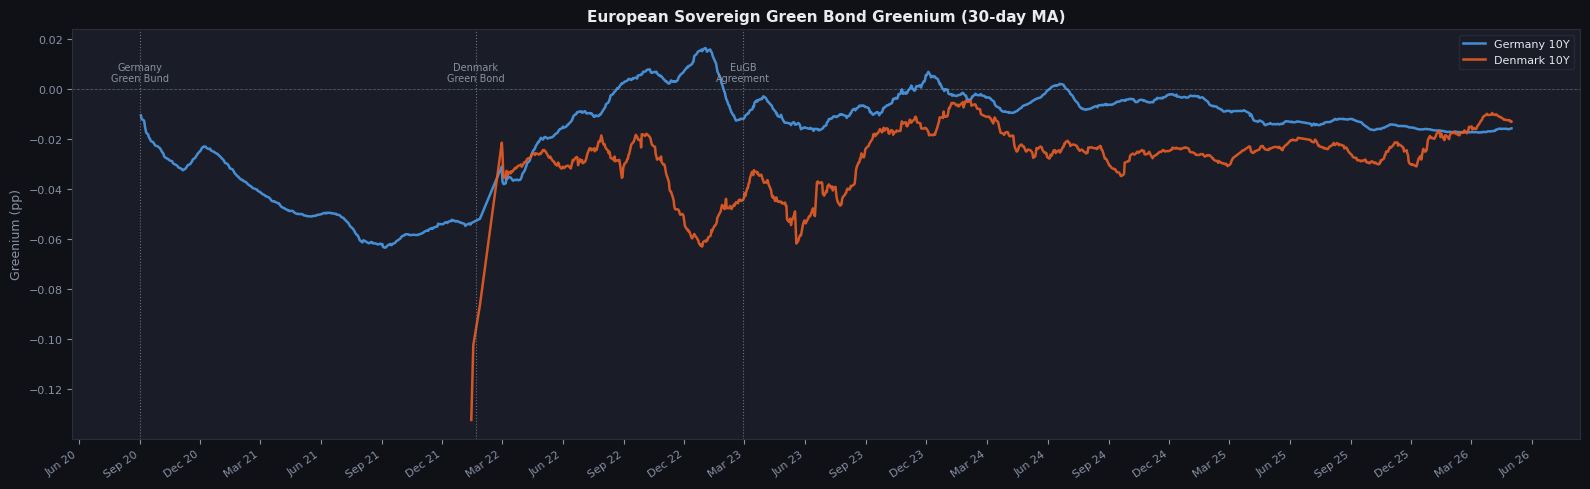

✓ Saved → ..\output\regression\plot1_greenium_timeseries_europe.png


In [25]:
fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor(BG); style_ax(ax)

pair_colors = {'Germany_10Y': BLUE, 'Denmark_10Y': ORANGE}

for pid, color in pair_colors.items():
    sub = panel[panel['pair_id']==pid].sort_values('date')
    ax.plot(sub.set_index('date')['greenium'].rolling('30D').mean(),
            color=color, linewidth=1.8, label=pid.replace('_',' '), alpha=0.9)

for edate, elabel in EVENTS.items():
    ax.axvline(pd.Timestamp(edate), color=GRAY, linewidth=0.8, linestyle=':', alpha=0.7)
    ax.text(pd.Timestamp(edate), panel['greenium'].quantile(0.93),
            elabel, fontsize=7, color=GRAY, ha='center', va='bottom')

ax.axhline(0, color=GRAY, linewidth=0.6, linestyle='--', alpha=0.5)
ax.set_title('European Sovereign Green Bond Greenium (30-day MA)',
             fontsize=11, fontweight='bold', color=WHITE)
ax.set_ylabel('Greenium (pp)', color=GRAY, fontsize=9)
ax.legend(fontsize=8, facecolor=PANEL_BG, edgecolor='#2a2d3a', labelcolor=WHITE)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right')
plt.tight_layout()

out = os.path.join(OUTPUT_FOLDER, 'plot1_greenium_timeseries_europe.png')
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show(); print(f"✓ Saved → {out}")


## 6.2 — Coefficient Plot (M1–M4)


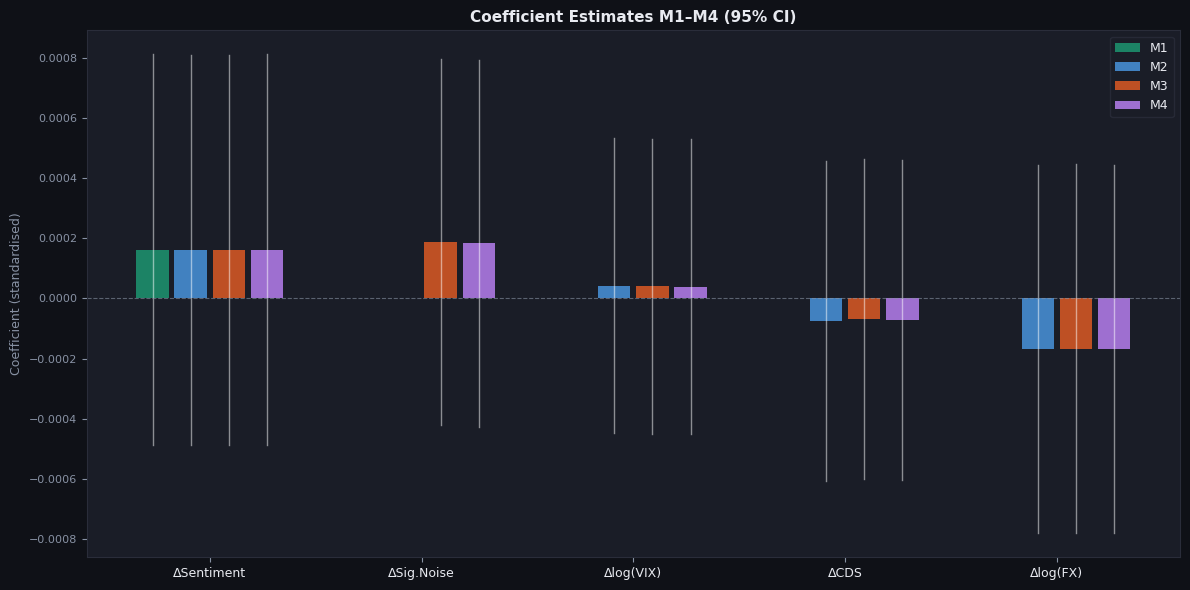

✓ Saved → ..\output\regression\plot2_coefficients.png


In [26]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG); style_ax(ax)

vars_plot = ['sentiment_fd_z','signaling_noise_fd_z','log_vix_fd_z','cds_fd_z','log_fx_fd_z']
vlbls     = {'sentiment_fd_z':'ΔSentiment','signaling_noise_fd_z':'ΔSig.Noise',
             'log_vix_fd_z':'Δlog(VIX)','cds_fd_z':'ΔCDS','log_fx_fd_z':'Δlog(FX)'}
colors_m  = [TEAL, BLUE, ORANGE, PURPLE]
x = np.arange(len(vars_plot)); w = 0.18

for mi, (mn, col) in enumerate(zip(['M1','M2','M3','M4'], colors_m)):
    res   = results[mn]
    coefs = [res.params.get(v, np.nan) for v in vars_plot]
    ci    = res.conf_int(alpha=0.05)
    lo    = [ci.loc[v,0] if v in ci.index else np.nan for v in vars_plot]
    hi    = [ci.loc[v,1] if v in ci.index else np.nan for v in vars_plot]
    pos   = x + (mi - 2 + 0.5) * w
    ax.bar(pos, coefs, w*0.85, color=col, alpha=0.8, label=mn)
    for p,l,h in zip(pos,lo,hi):
        if not np.isnan(l): ax.plot([p,p],[l,h], color='white', linewidth=1.0, alpha=0.5)

ax.axhline(0, color=GRAY, linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels([vlbls[v] for v in vars_plot], fontsize=9, color=WHITE)
ax.set_title('Coefficient Estimates M1–M4 (95% CI)',
             fontsize=11, fontweight='bold', color=WHITE)
ax.set_ylabel('Coefficient (standardised)', color=GRAY, fontsize=9)
ax.legend(fontsize=9, facecolor=PANEL_BG, edgecolor='#2a2d3a', labelcolor=WHITE)
plt.tight_layout()


out = os.path.join(OUTPUT_FOLDER, 'plot2_coefficients.png')
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show(); print(f"✓ Saved → {out}")


## 6.3 — Sentiment vs Greenium Scatter

Plots daily sentiment (V2Tone) against the greenium for Germany and Denmark with OLS fit lines. A positive slope would support H1 (higher climate sentiment → wider greenium).


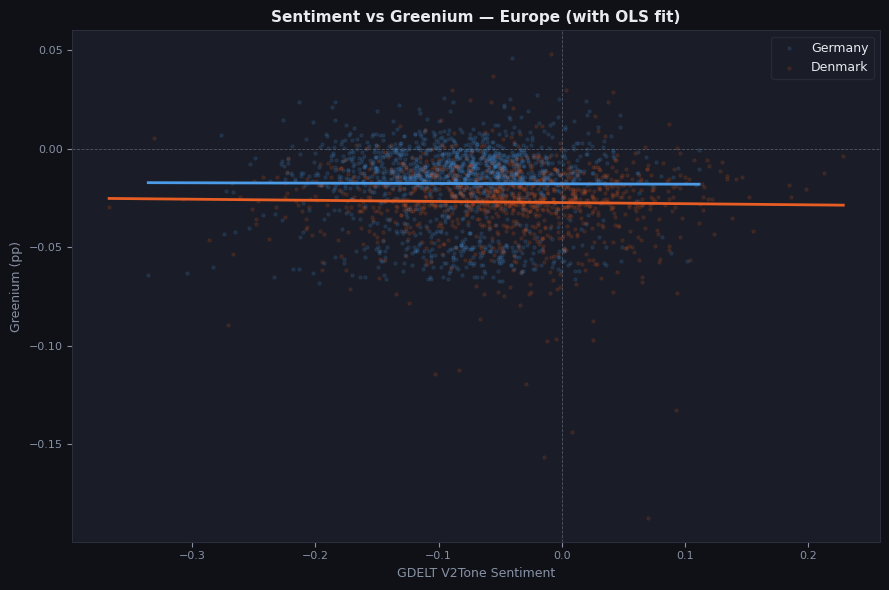

✓ Saved → ..\output\regression\plot3_sentiment_scatter_europe.png


In [27]:
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor(BG); style_ax(ax)

for country, color in [('Germany',BLUE),('Denmark',ORANGE)]:
    sub = panel[panel['country']==country].dropna(subset=['sentiment','greenium'])
    ax.scatter(sub['sentiment'], sub['greenium'], alpha=0.12, s=5, color=color, label=country)
    z  = np.polyfit(sub['sentiment'], sub['greenium'], 1)
    xr = np.linspace(sub['sentiment'].min(), sub['sentiment'].max(), 100)
    ax.plot(xr, np.poly1d(z)(xr), color=color, linewidth=2.0)

ax.axhline(0, color=GRAY, linewidth=0.6, linestyle='--', alpha=0.5)
ax.axvline(0, color=GRAY, linewidth=0.6, linestyle='--', alpha=0.5)
ax.set_xlabel('GDELT V2Tone Sentiment', fontsize=9)
ax.set_ylabel('Greenium (pp)', fontsize=9)
ax.set_title('Sentiment vs Greenium — Europe (with OLS fit)',
             fontsize=11, fontweight='bold', color=WHITE)
ax.legend(fontsize=9, facecolor=PANEL_BG, edgecolor='#2a2d3a', labelcolor=WHITE)
plt.tight_layout()

out = os.path.join(OUTPUT_FOLDER, 'plot3_sentiment_scatter_europe.png')
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show(); print(f"✓ Saved → {out}")


## 6.4 — Greenium by Signaling Noise Quartile

Plots mean greenium by quartile of daily V2Tone standard deviation (Signaling Noise). A downward slope (Q1→Q4) would support H2 — higher noise (more contradictory political signals) associated with lower greenium.


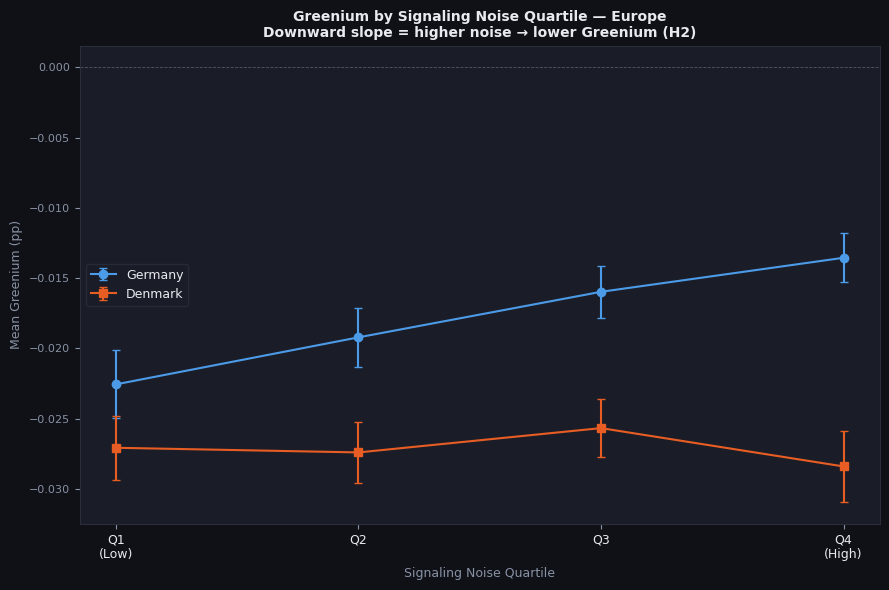

✓ Saved → ..\output\regression\plot4_noise_quartiles_europe.png


In [28]:
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor(BG); style_ax(ax)

p4 = panel.dropna(subset=['signaling_noise','greenium']).copy()
p4['noise_q'] = pd.qcut(p4['signaling_noise'], 4,
                         labels=['Q1\n(Low)','Q2','Q3','Q4\n(High)'])

for country, color, marker in [('Germany', BLUE, 'o'), ('Denmark', ORANGE, 's')]:
    sub   = p4[p4['country']==country]
    means = sub.groupby('noise_q', observed=True)['greenium'].mean()
    cis   = sub.groupby('noise_q', observed=True)['greenium'].sem() * 1.96

    # Only plot quartiles that actually exist for this country
    x_vals = [i for i, q in enumerate(['Q1\n(Low)','Q2','Q3','Q4\n(High)'])
               if q in means.index]
    y_vals = means.reindex(['Q1\n(Low)','Q2','Q3','Q4\n(High)']).dropna().values
    e_vals = cis.reindex(['Q1\n(Low)','Q2','Q3','Q4\n(High)']).dropna().values

    ax.errorbar(x_vals, y_vals, yerr=e_vals,
                marker=marker, color=color, linewidth=1.5, markersize=6,
                label=country, capsize=3)

ax.axhline(0, color=GRAY, linewidth=0.6, linestyle='--', alpha=0.5)
ax.set_xticks(range(4))
ax.set_xticklabels(['Q1\n(Low)','Q2','Q3','Q4\n(High)'], color=WHITE, fontsize=9)
ax.set_xlabel('Signaling Noise Quartile', fontsize=9)
ax.set_ylabel('Mean Greenium (pp)', fontsize=9)
ax.set_title('Greenium by Signaling Noise Quartile — Europe\n'
             'Downward slope = higher noise → lower Greenium (H2)',
             fontsize=10, fontweight='bold', color=WHITE)
ax.legend(fontsize=9, facecolor=PANEL_BG, edgecolor='#2a2d3a', labelcolor=WHITE)
plt.tight_layout()

out = os.path.join(OUTPUT_FOLDER, 'plot4_noise_quartiles_europe.png')
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show(); print(f"✓ Saved → {out}")

---
# Part 7 — Save Outputs


In [29]:
csv_dir = os.path.join(ROOT, 'data', 'processed', 'regression_europe')
os.makedirs(csv_dir, exist_ok=True)
out_csv = os.path.join(csv_dir, 'regression_panel_europe.csv')
save_cols = ['date','country','tenor','pair_id','greenium','ytm_green','ytm_conv',
             'sentiment','signaling_noise','vix','cds','fx','post']
panel[save_cols].to_csv(out_csv, index=False)
print(f"✓ Panel saved → {out_csv}")
print(f"  Shape: {panel[save_cols].shape}")
print()
print("All outputs in:", OUTPUT_FOLDER)
print(f"Panel CSV:  {out_csv}")
print(f"Plot files: {OUTPUT_FOLDER}")
print("  ├── plot1_greenium_timeseries_europe.png")
print("  ├── plot2_coefficients.png")
print("  ├── plot3_sentiment_scatter_europe.png")
print("  └── plot4_noise_quartiles.png")


✓ Panel saved → ..\data\processed\regression_europe\regression_panel_europe.csv
  Shape: (2484, 13)

All outputs in: ..\output\regression
Panel CSV:  ..\data\processed\regression_europe\regression_panel_europe.csv
Plot files: ..\output\regression
  ├── plot1_greenium_timeseries_europe.png
  ├── plot2_coefficients.png
  ├── plot3_sentiment_scatter_europe.png
  └── plot4_noise_quartiles.png
